In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Import basic libraries

In [2]:
import sys
import sklearn
# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


import tarfile
import urllib
import seaborn as sns
import math

# Get the data 

In [3]:
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
gender_submission_data = pd.read_csv("/kaggle/input/competitions/titanic/gender_submission.csv")


# EDA


## Data Cleaning

In [6]:
# explore the train data 
train_data.info()
# numerical cols 
num_cols = train_data.select_dtypes(include=['number'])
print("numerical columns in the data set:", num_cols.shape[1])
# categorical cols
cat_cols = train_data.select_dtypes(include=['object'])
print("categorical columns in the data set:", cat_cols.shape[1])

# Now for test data
num_cols_test = test_data.select_dtypes(include=['number'])
cat_cols_test = test_data.select_dtypes(include=['object'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
numerical columns in the data set: 7
categorical columns in the data set: 5


In [7]:
# Missing data 
print("missing data:")
train_data.isnull().sum()

missing data:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# lets impute the age with the most frequent value

mode_age = train_data["Age"].mode()[0]
train_data["Age"] = train_data["Age"].fillna(mode_age)
test_data["Age"] = test_data["Age"].fillna(mode_age)

# For the Cabin the NaN lets impute with the zero
train_data["Cabin"] = train_data["Cabin"].fillna("0")
test_data["Cabin"] = test_data["Cabin"].fillna("0")

# For the Embarked lets impute with the frequent value
mode_embarked = train_data["Embarked"].mode()[0]
train_data["Embarked"] = train_data["Embarked"].fillna(mode_embarked)
test_data["Embarked"] = test_data["Embarked"].fillna(mode_embarked)

# For the Fare lest drop the row
mean_fare = train_data["Fare"].mean()
train_data = train_data.fillna(mean_fare)
test_data = test_data.fillna(mean_fare)

In [9]:
# Missing data 
print("missing data:")
print("null values for the train data: \n", train_data.isnull().sum())
print("null values for the test data: \n", test_data.isnull().sum())

missing data:
null values for the train data: 
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
null values for the test data: 
 PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [10]:
print("duplicated values:")
print("Train data: \n", train_data.duplicated().sum())
print("Test data: \n", test_data.duplicated().sum())

duplicated values:
Train data: 
 0
Test data: 
 0


In [11]:
# lets convert the age in integer

train_data["Age"] = train_data["Age"].astype(int)

test_data["Age"] = test_data["Age"].astype(int)

In [12]:
# titles to keep in the training (most common)
titles = ["Master", "Dr", "Miss", "Mr", "Mrs"]

# lets extract the title of the passenger name instead of the all name
train_data["Title"] = train_data["Name"].str.extract(r" ([A-Za-z]+)\.")

# keep the train column just with the common titles 
train_data["Title"] = train_data["Title"].where(train_data["Title"].isin(titles), "unknown")

#add this to the test data 
test_data["Title"] = test_data["Name"].str.extract(r" ([A-Za-z]+)\.")

# the same for the test 
test_data["Title"] = test_data["Title"].where(test_data["Title"].isin(titles), "unknown")


In [13]:
# also add to the categorical data frame
cat_cols["Title"] = cat_cols["Name"].str.extract(r" ([A-Za-z]+)\.")



cat_cols_test["Title"] = cat_cols_test["Name"].str.extract(r" ([A-Za-z]+)\.")



cat_cols["Title"] = cat_cols["Title"].where(cat_cols["Title"].isin(titles), "unknown")



cat_cols_test["Title"] = cat_cols_test["Title"].where(cat_cols_test["Title"].isin(titles), "unknown")

In [14]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,0,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,0,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,0,S,Mr


## Data Exploration

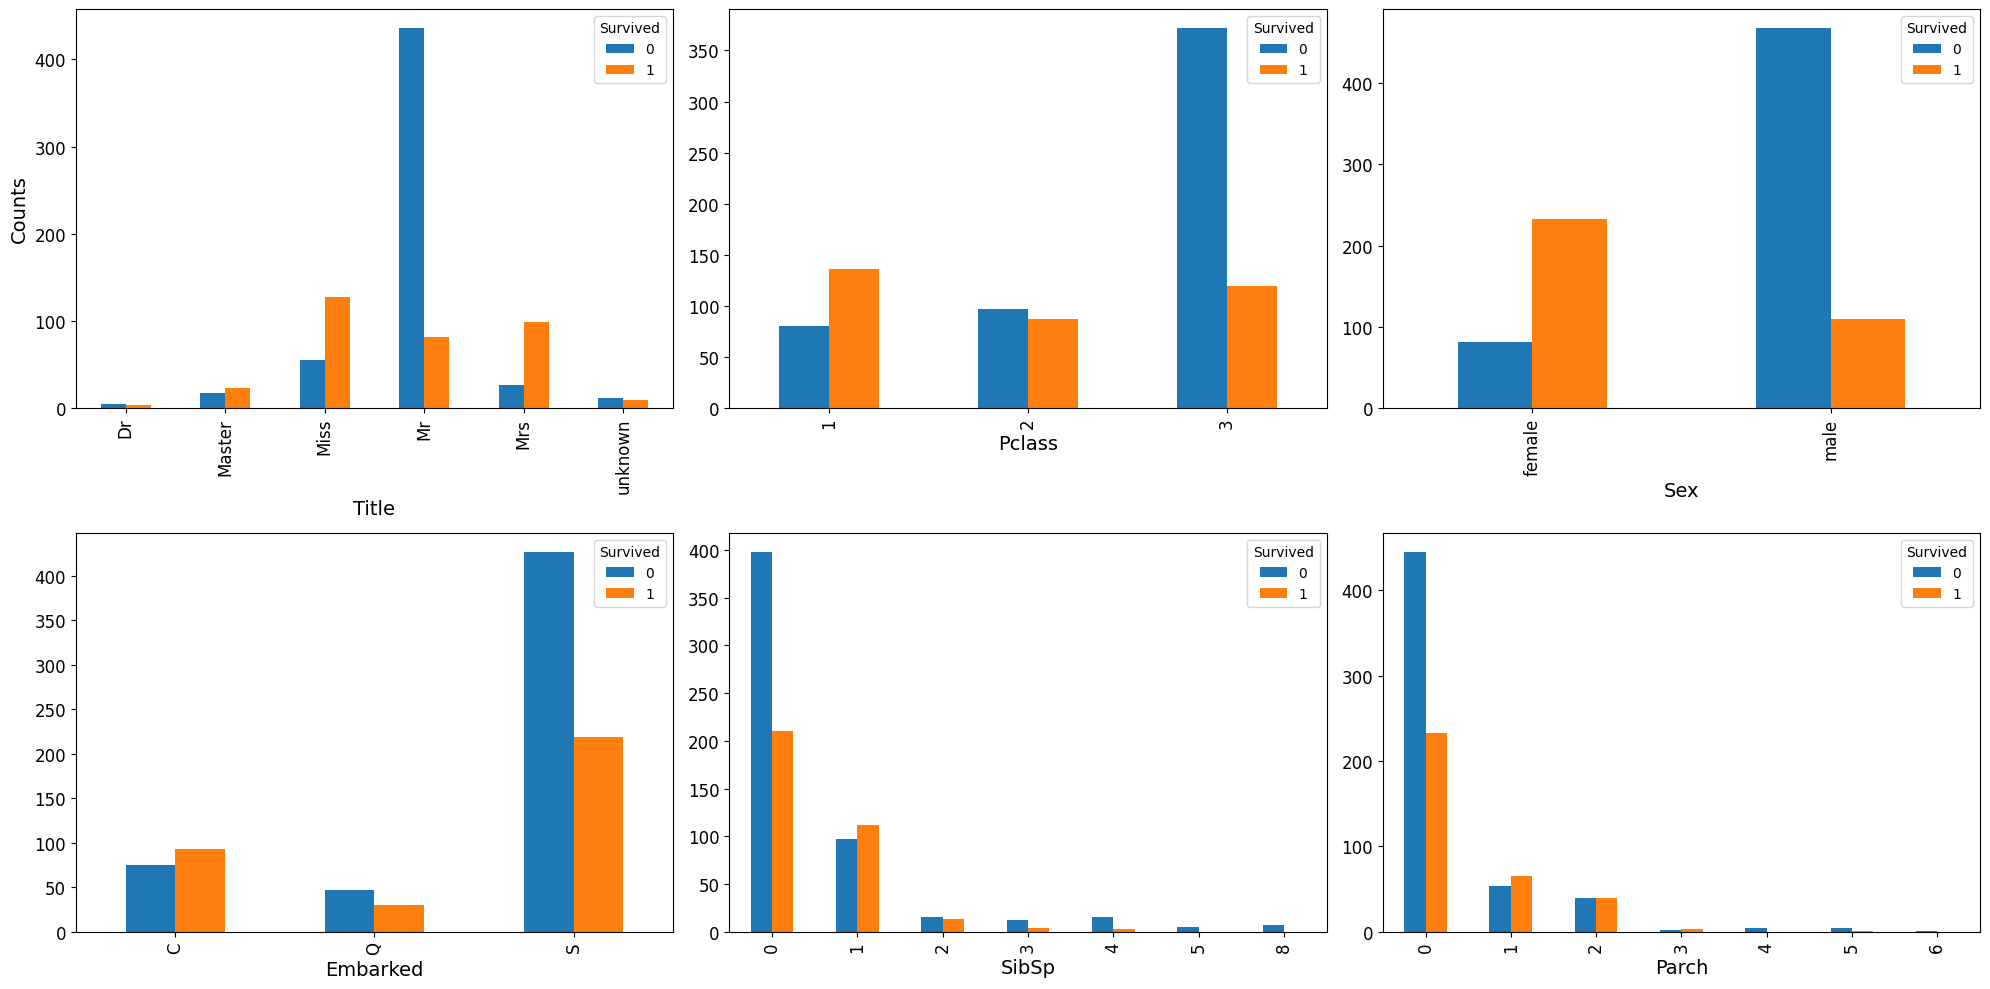

Fraction in % of people that survive and die: Survived
0    61.616162
1    38.383838
Name: count, dtype: float64


In [15]:
# lets make a bar distribution based on whether or not survived 

features_list = ["Title", "Pclass", "Sex", "Embarked", "SibSp", "Parch"]

fig, axs = plt.subplots(nrows=2, ncols=3,figsize = (20,10))
axs = axs.flatten()
for i, feature in enumerate(features_list):
    pd.crosstab(train_data[feature], train_data["Survived"]).plot(kind = "bar", ax = axs[i])
    axs[0].set_ylabel("Counts")
plt.tight_layout()
plt.show()
plt.close()

# fraction of people that survive
survive_frac = train_data["Survived"].value_counts()/len(train_data) 
print(f"Fraction in % of people that survive and die: {survive_frac*100}")



<Figure size 640x480 with 0 Axes>

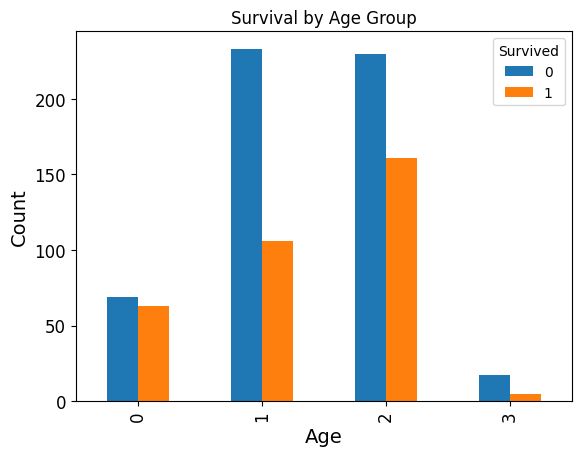

In [16]:
# lets understand the distribution of the age 

age_copy = train_data.copy()

age_copy["Age"] = pd.cut(age_copy["Age"], bins = [0, 18, 25, 60, 100], 
                        labels = [0, 1, 2, 3])

# where 0 = child, 1 = young, 2 = adult, 3 = senior

# now lets group the survived people by its age
plt.figure()
pd.crosstab(age_copy["Age"], age_copy["Survived"]).plot(kind = "bar")
plt.ylabel("Count")
plt.title("Survival by Age Group")
plt.show()
plt.close()

The most frequent fare value is: 8.05 US


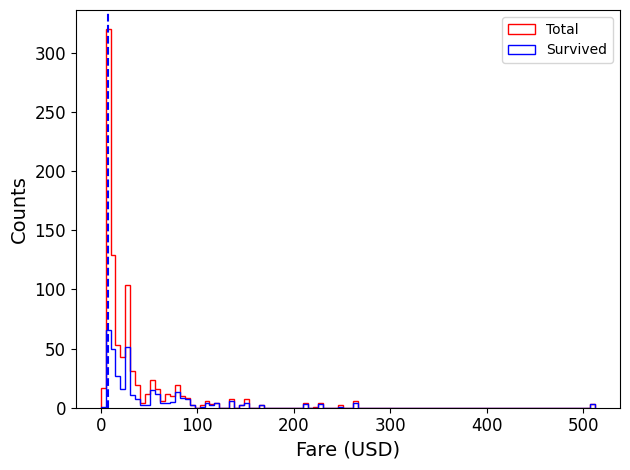

In [17]:
# fare distribution
fare = train_data["Fare"]
# lets mask the fares that belong to survival people
mask = train_data["Survived"] == 1

mode_fare = fare.mode()[0]
print(f"The most frequent fare value is: {mode_fare:.2f} US")
plt.figure()
plt.hist(fare, bins = 100, histtype = 'step', color = 'r', label = 'Total')
plt.hist(fare[mask], bins = 100, histtype = 'step', color = 'b', label = 'Survived')
plt.axvline(mode_fare, color = 'b', linestyle = '--')
plt.xlabel("Fare (USD)")
plt.ylabel("Counts")
plt.tight_layout()
plt.legend()
plt.show()
plt.close()

## Feature engine


In [18]:
# lets understand the correlations with the response variable separating the numerical and categorical attributes
# make a copy of the numerical dataframa

num_cols_copy = num_cols.copy()

# if the passenger go alone 
num_cols_copy["IsAlone"] = (num_cols["SibSp"] + num_cols["Parch"] + 1 == 1).astype(int)

corr_matrix_num = num_cols_copy.corr()["Survived"].sort_values(ascending = False)
print("---------------- Correlation with numerical variables ------------------------")
#corr_matrix_num
corr_matrix_num[abs(corr_matrix_num) > 0.01]

# Is Alone has a good anticorrelation 

---------------- Correlation with numerical variables ------------------------


Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
IsAlone    -0.203367
Pclass     -0.338481
Name: Survived, dtype: float64

In [19]:
#lets handle categorical variables to explore correlations
#make a copy of the categorical dataframe
cat_cols_copy = cat_cols.copy()

#lets try implement a new feature
cat_cols_copy["HasCabin"] = cat_cols["Cabin"].notnull().astype(int)
# lets encode some categorical fetures to understand correlations with survived variable 
encoded_train_set = pd.get_dummies(cat_cols_copy[["Sex", "Cabin", "Embarked", "HasCabin"]])
encoded_train_set["Survived"] = num_cols["Survived"]
# correlation matrix
corr_matrix_cat = encoded_train_set.corr()["Survived"].sort_values(ascending = False)
print("---------------- Strongest correlation with categorical variables ------------------------")
# filter the strongest correlations
corr_matrix_cat[abs(corr_matrix_cat) > 0.01]

# Has Cabin has a good correlation

---------------- Strongest correlation with categorical variables ------------------------


Survived         1.000000
Sex_female       0.543351
HasCabin         0.316912
Embarked_C       0.168240
Cabin_B96 B98    0.085083
                   ...   
Cabin_C124      -0.037436
Cabin_F G73     -0.037436
Cabin_D26       -0.037436
Embarked_S      -0.155660
Sex_male        -0.543351
Name: Survived, Length: 152, dtype: float64

In [20]:
# From the below analysis, lets add the new features to the data frame

train_data["PassengerIsAlone"] = (train_data["SibSp"] + train_data["Parch"] + 1 == 1).astype(int)

train_data["PassengerHasCabin"] = train_data["Cabin"].notnull().astype(int)

# lets add this features also into test data

test_data["PassengerIsAlone"] = (test_data["SibSp"] + test_data["Parch"] + 1 == 1).astype(int)
test_data["PassengerHasCabin"] = test_data["Cabin"].notnull().astype(int)

train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,PassengerIsAlone,PassengerHasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,0,S,Mr,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,Mrs,0,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,0,S,Miss,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,Mrs,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,0,S,Mr,1,1


In [21]:
# Lets transform all into numerical features

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# lets drop the name from the categorical data frame
cat_cols = cat_cols.drop(["Name", "Ticket", "Cabin"], axis = 1)
cat_cols_test = cat_cols_test.drop(["Name", "Ticket", "Cabin"], axis = 1)

# for the train data set 
encoded = encoder.fit_transform(train_data[cat_cols.columns])
encoded_df = pd.DataFrame(encoded,
                          columns=encoder.get_feature_names_out(cat_cols.columns),
                          index=train_data.index
                         )
train_data = pd.concat([train_data.drop(columns=cat_cols.columns), encoded_df],axis=1)

# something similar to test

encoded_test = encoder.transform(test_data[cat_cols_test.columns])
encoded_test_df = pd.DataFrame(encoded_test, 
                               columns=encoder.get_feature_names_out(cat_cols_test.columns),
                               index=test_data.index
                              )
test_data = pd.concat([test_data.drop(columns=cat_cols_test.columns), encoded_test_df], axis=1)

#drop columns also from the main frame

train_data = train_data.drop(["Name", "Ticket", "Cabin"], axis = 1)

#drop columns in the test data 

test_data = test_data.drop(["Name", "Ticket", "Cabin"], axis = 1)

train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'PassengerIsAlone', 'PassengerHasCabin', 'Sex_female', 'Sex_male',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Dr', 'Title_Master',
       'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_unknown'],
      dtype='object')

# Trainining

In [22]:
train_data_prep = train_data.copy()

test_data_prep = test_data.copy()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error

X_train = train_data_prep.drop(["Survived"], axis = 1)
y_train = train_data_prep["Survived"]

# starting with a random forest classifier with regularization
model = RandomForestClassifier(n_estimators=300, class_weight="balanced", max_depth = 6,
                               min_samples_leaf=5, random_state=42)

# Evaluating Performance

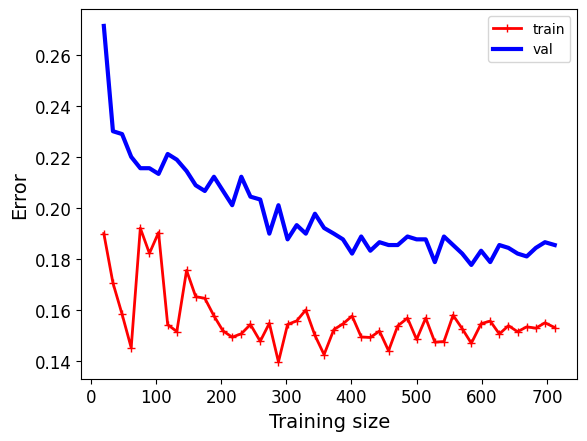

In [24]:
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state=42)
    train_errors, val_errors = [], []
    sizes = np.linspace(20, len(X_train), 50, dtype=int)
    for m in sizes:
        train_err, val_err = [], []
        for _ in range(5):
            idx = np.random.permutation(len(X_train))[:m]
            model.fit(X_train.iloc[idx], y_train.iloc[idx])
            
            y_train_predict = model.predict(X_train.iloc[idx])
            y_val_predict = model.predict(X_val)
            
            train_err.append(1-accuracy_score(y_train.iloc[idx], y_train_predict))
            val_err.append(1- accuracy_score(y_val, y_val_predict))
            
        train_errors.append(np.mean(train_err))
        val_errors.append(np.mean(val_err))
        
    plt.plot(sizes, train_errors, "r-+", linewidth=2, label="train")
    plt.plot(sizes, val_errors, "b-", linewidth=3, label="val")
    plt.xlabel("Training size")
    plt.ylabel("Error")
    plt.legend()
    
plot_learning_curves(model, X_train, y_train)

In [25]:
#log_reg.fit(X_train, y_train)

model.fit(X_train, y_train)

# validation scores
scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

print("Accuracy:", scores.mean())



Accuracy: 0.8248760278701903


In [26]:
# lets make predictions on the test data
X_test = test_data_prep
# predictions
predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId': X_test.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
